# VLSTM: Variable-Selection + LSTM for End-to-End Portfolio Learning

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 17_portfolio_construction/12_vlstm_portfolio.py
> ```

Saly-Kaufmann et al. (2026) identify **VLSTM** — a TFT-style variable-selection block in front of an LSTM encoder — as a strong end-to-end portfolio architecture under a shared volatility-targeted long-short pipeline.

**Learning objectives**:
- Build a TFT-style Gated Residual Network (GRN) and Variable Selection Network (VSN)
- Stack the VSN in front of an LSTM to form the VLSTM encoder
- Emit a scalar signal $p_{i,t} \in (-1,1)$ via tanh and convert it to a volatility-targeted long-short position
- Train with a cost-aware pooled Sharpe loss on realized portfolio returns
- Compare VLSTM to the plain LSTM baseline (`11_dl_portfolio_allocation`) and heuristic allocators

**Book reference**: Chapter 17, §17.8 (Deep Learning for Portfolio Construction)

**Prerequisites**: `11_dl_portfolio_allocation`

## 1. Setup

In [1]:
"""VLSTM portfolio allocator — TFT-style variable selection + LSTM under a volatility-targeted portfolio layer."""

import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from data import load_etfs
from utils.paths import get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds

In [2]:
MAX_SYMBOLS = 0  # 0 = full ETF universe.
N_EPOCHS = 200
SEQ_LEN = 63  # ~3 months lookback, matches notebook 11.
D_MODEL = 32  # GRN / VSN hidden dimension.
SEED = 42
LSTM_HIDDEN = 64
DROPOUT = 0.1
LR = 1e-3
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 32
VOL_TARGET_ANN = 0.15  # Target annualized portfolio volatility.
VOL_LOOKBACK = 63  # Rolling window for per-asset volatility estimate.
TURNOVER_COST_BPS = 5.0  # One-way cost in the loss (basis points).
COST_WEIGHT = 1.0  # Scales the turnover penalty in the loss.
USE_CACHED_MODEL_IF_AVAILABLE = True
SAVE_TRAINED_MODEL_TO_CACHE = True

In [3]:
OUTPUT_DIR = get_output_dir(17, "vlstm_portfolio")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_CACHE_PATH = OUTPUT_DIR / "vlstm_portfolio_cache.pt"
CANONICAL_OUTPUT_DIR = get_chapter_dir(17) / "output" / "vlstm_portfolio"
CANONICAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CANONICAL_MODEL_CACHE_PATH = CANONICAL_OUTPUT_DIR / "vlstm_portfolio_cache.pt"

Iterate unique cache candidate paths in priority order.

In [4]:
def iter_cache_candidates(*paths: Path):
    """Yield unique cache paths in priority order."""
    seen: set[Path] = set()
    for path in paths:
        resolved = path.resolve()
        if resolved not in seen:
            seen.add(resolved)
            yield path

Validate that a cached state dict matches the current model layout before loading.

In [5]:
def state_dict_is_compatible(model: nn.Module, state_dict: dict) -> tuple[bool, str]:
    """Return whether a cached state dict matches the current model layout."""
    if not isinstance(state_dict, dict):
        return False, "cache payload has no valid state_dict"
    expected = model.state_dict()
    if set(expected.keys()) != set(state_dict.keys()):
        return False, "parameter keys differ"
    for key, expected_tensor in expected.items():
        cached_shape = getattr(state_dict[key], "shape", None)
        if cached_shape != expected_tensor.shape:
            return False, f"shape mismatch at {key}"
    return True, ""

In [6]:
IN_TEST_OUTPUT_MODE = os.environ.get("ML4T_OUTPUT_DIR") is not None
if IN_TEST_OUTPUT_MODE:
    cache_exists = any(
        path.exists()
        for path in iter_cache_candidates(MODEL_CACHE_PATH, CANONICAL_MODEL_CACHE_PATH)
    )
    if not cache_exists:
        N_EPOCHS = min(N_EPOCHS, 20)
        print(f"Bootstrap cache mode: N_EPOCHS reduced to {N_EPOCHS}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

Device: cuda


## 2. Data: ETF Universe

Same universe as `11_dl_portfolio_allocation` so the architectural comparison is
apples-to-apples on the same test period.

In [7]:
US_EQUITY = ["SPY", "QQQ", "IWM", "VTV", "VUG", "MDY"]
INTERNATIONAL = ["EFA", "EEM", "VEA", "VWO"]
FIXED_INCOME = ["AGG", "TLT", "LQD", "HYG", "TIP", "SHY", "IEF"]
ALTERNATIVES = ["GLD", "SLV", "VNQ", "DBC"]
SECTORS = ["XLF", "XLE", "XLK", "XLV", "XLI", "XLU", "XLP", "XLY"]
UNIVERSE = [*US_EQUITY, *INTERNATIONAL, *FIXED_INCOME, *ALTERNATIVES, *SECTORS]

if MAX_SYMBOLS > 0:
    UNIVERSE = UNIVERSE[:MAX_SYMBOLS]

In [8]:
etf_data = load_etfs()
prices = (
    etf_data.filter(pl.col("symbol").is_in(UNIVERSE))
    .select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)
prices = prices[[c for c in UNIVERSE if c in prices.columns]]
coverage_threshold = max(1, int(prices.shape[1] * 0.8))
prices = prices.dropna(thresh=coverage_threshold).ffill().bfill()
UNIVERSE = list(prices.columns)
N_ASSETS = len(UNIVERSE)

print(f"Price panel: {prices.shape[0]} dates × {N_ASSETS} assets")
print(f"Date range:  {prices.index[0]:%Y-%m-%d} → {prices.index[-1]:%Y-%m-%d}")

Price panel: 5031 dates × 29 assets
Date range:  2006-01-03 → 2025-12-31


## 3. Feature Engineering and Volatility Estimate

Features match notebook 11 for a like-for-like comparison: multi-horizon returns and
21-day realized volatility. The volatility-targeting layer uses a longer rolling
estimate that feeds into the position sizing rather than into the model input.

In [9]:
returns = prices.pct_change().fillna(0.0)

HORIZONS = [1, 5, 21, 63]
features_list = [(prices / prices.shift(h) - 1.0).fillna(0.0).values for h in HORIZONS]
features_list.append(returns.rolling(21, min_periods=5).std().fillna(0.0).values)
features = np.stack(features_list, axis=-1).astype(np.float32)
N_FEATURES = features.shape[-1]

# Volatility estimate for the position layer (used for vol targeting).
vol_estimate = returns.rolling(VOL_LOOKBACK, min_periods=21).std().ffill().fillna(returns.std())
vol_estimate = vol_estimate.clip(lower=1e-4).values.astype(np.float32)

realized_returns = returns.values.astype(np.float32)
fwd_returns = returns.shift(-1).fillna(0.0).values.astype(np.float32)

print(f"Feature tensor: {features.shape} (T, N, F)")
print(f"Vol estimate:   {vol_estimate.shape}")

Feature tensor: (5031, 29, 5) (T, N, F)
Vol estimate:   (5031, 29)


## 4. Train / Validation / Test Split

Walk-forward: 60/20/20. Same split rule as notebook 11.

In [10]:
dates = prices.index
n_dates = len(dates)
train_end = int(n_dates * 0.6)
val_end = int(n_dates * 0.8)

print(f"Train: {dates[0]:%Y-%m-%d} → {dates[train_end - 1]:%Y-%m-%d} ({train_end} days)")
print(
    f"Val:   {dates[train_end]:%Y-%m-%d} → {dates[val_end - 1]:%Y-%m-%d} ({val_end - train_end} days)"
)
print(f"Test:  {dates[val_end]:%Y-%m-%d} → {dates[-1]:%Y-%m-%d} ({n_dates - val_end} days)")

Train: 2006-01-03 → 2017-12-27 (3018 days)
Val:   2017-12-28 → 2021-12-27 (1006 days)
Test:  2021-12-28 → 2025-12-31 (1007 days)


## 5. Dataset

Each training example is a sliding window of features, the realized-return path, and
the per-asset volatility estimate over the same window.

In [11]:
class VLSTMDataset(Dataset):
    """Sliding windows with features, forward returns, and vol estimates."""

    def __init__(self, features, fwd_ret, vol_est, start_idx, end_idx, seq_len):
        self.features = features
        self.fwd_ret = fwd_ret
        self.vol_est = vol_est
        self.seq_len = seq_len
        self.indices = np.arange(
            max(start_idx, seq_len - 1),
            min(end_idx, len(features) - 1) - seq_len + 1,
        )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]
        sl = slice(t - self.seq_len + 1, t + 1)
        return (
            torch.from_numpy(self.features[sl]),
            torch.from_numpy(self.fwd_ret[sl]),
            torch.from_numpy(self.vol_est[sl]),
        )


train_ds = VLSTMDataset(features, fwd_returns, vol_estimate, 0, train_end, SEQ_LEN)
val_ds = VLSTMDataset(features, fwd_returns, vol_estimate, train_end, val_end, SEQ_LEN)
test_ds = VLSTMDataset(features, fwd_returns, vol_estimate, val_end, n_dates, SEQ_LEN)

print(f"Train windows: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Train windows: 2894, Val: 944, Test: 944


## 6. Gated Residual Network (GRN)

The TFT building block (Lim et al. 2021). The GRN applies a non-linear transformation
gated by a GLU and wrapped in a residual connection with LayerNorm:

$$\eta_2 = W_2 \cdot \text{ELU}(W_1 x + b_1) + b_2, \quad \text{GRN}(x) = \text{LayerNorm}(x + \text{GLU}(\eta_2)).$$

GLU gating lets the network suppress features whose contribution is noise, which is
crucial in the financial setting where most inputs are weakly predictive.

In [12]:
class GatedResidualNetwork(nn.Module):
    """TFT-style gated residual network with optional skip projection."""

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.skip = nn.Identity() if input_dim == output_dim else nn.Linear(input_dim, output_dim)
        self.dense1 = nn.Linear(input_dim, hidden_dim)
        self.dense2 = nn.Linear(hidden_dim, output_dim)
        self.gate = nn.Linear(output_dim, 2 * output_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        skip = self.skip(x)
        h = F.elu(self.dense1(x))
        h = self.dense2(h)
        h = self.dropout(h)
        a, b = self.gate(h).chunk(2, dim=-1)
        gated = a * torch.sigmoid(b)
        return self.norm(skip + gated)

## 7. Variable Selection Network (VSN)

For each (asset, time) cell, the VSN projects every scalar feature through its own GRN
into a $d$-dimensional embedding, computes softmax selection weights from the flattened
feature vector, and returns the selection-weighted sum of embeddings.

$$v_{i,t} = \text{softmax}_f \big(\text{GRN}_{\text{sel}}(x_{i,t})\big), \qquad
h_{i,t} = \sum_f v_{i,t,f} \cdot \text{GRN}_f(x_{i,t,f}).$$

This is the core ingredient that distinguishes VLSTM from a plain LSTM encoder: the
model learns which features are worth listening to at each point in the window.

In [13]:
class VariableSelectionNetwork(nn.Module):
    """TFT-style variable selection over per-feature GRN embeddings."""

    def __init__(self, n_features: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model
        self.feature_grns = nn.ModuleList(
            [GatedResidualNetwork(1, d_model, d_model, dropout) for _ in range(n_features)]
        )
        self.selector = GatedResidualNetwork(n_features, d_model, n_features, dropout)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # x: (B, T, N, F) with per-feature scalar inputs.
        sel_logits = self.selector(x)  # (B, T, N, F)
        sel_weights = torch.softmax(sel_logits, dim=-1)

        embeddings = []
        for f_idx, grn in enumerate(self.feature_grns):
            e = grn(x[..., f_idx : f_idx + 1])  # (B, T, N, d_model)
            embeddings.append(e)
        embeddings = torch.stack(embeddings, dim=-2)  # (B, T, N, F, d_model)

        gated = sel_weights.unsqueeze(-1) * embeddings
        return gated.sum(dim=-2), sel_weights

## 8. VLSTM: Variable Selection + Shared-Weight LSTM + Scalar Head

Every asset is processed by the same LSTM (shared weights, per-asset state), which is
standard for this class of models: the architecture is the inductive bias and the asset
identity is expressed only through its feature sequence. The LSTM output is projected
through a final GRN and a linear scalar head. A `tanh` activation bounds the raw signal
to $(-1, 1)$.

In [14]:
class VLSTM(nn.Module):
    """VSN + per-asset shared LSTM + scalar signal head."""

    def __init__(
        self,
        n_features: int,
        d_model: int,
        lstm_hidden: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.vsn = VariableSelectionNetwork(n_features, d_model, dropout)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
        )
        self.post_grn = GatedResidualNetwork(lstm_hidden, lstm_hidden, lstm_hidden, dropout)
        self.head = nn.Linear(lstm_hidden, 1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # x: (B, T, N, F) -> h_vsn: (B, T, N, d_model)
        h_vsn, sel_weights = self.vsn(x)

        b, t, n, d = h_vsn.shape
        # Run the shared LSTM per asset by batching (B*N) sequences of length T.
        seq = h_vsn.permute(0, 2, 1, 3).reshape(b * n, t, d)
        out, _ = self.lstm(seq)
        out = self.post_grn(out)
        signal = torch.tanh(self.head(out)).squeeze(-1)  # (B*N, T)
        signal = signal.reshape(b, n, t).permute(0, 2, 1).contiguous()  # (B, T, N)

        return signal, sel_weights

In [15]:
model = VLSTM(
    n_features=N_FEATURES,
    d_model=D_MODEL,
    lstm_hidden=LSTM_HIDDEN,
    dropout=DROPOUT,
).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 59,148


## 9. Volatility-Targeted Long-Short Position Layer

The scalar signal $p_{i,t} \in (-1,1)$ is converted into a position size by
volatility targeting:

$$w_{i,t} = \frac{\sigma^{\*}}{\sqrt{252} \cdot \hat{\sigma}_{i,t}} \cdot p_{i,t}.$$

The annualized target $\sigma^{\*}$ is divided by the annualized asset-level volatility
estimate $\sqrt{252} \hat{\sigma}_{i,t}$, so each asset's notional exposure is scaled to
contribute the same ex-ante risk before the signal tilts it long or short. Portfolio
returns are the average over the N-asset book, and turnover costs are subtracted inside
the computation graph so the model sees implementation friction during training.

In [16]:
def vol_scaled_positions(signal: torch.Tensor, vol_est: torch.Tensor) -> torch.Tensor:
    """Map (B, T, N) signal in (-1, 1) to a volatility-targeted position size.

    Per-asset exposure is scaled by 1/N so that the book-level sum of per-asset
    contributions has the target volatility level (rather than sqrt(N) times it).
    """
    daily_vol = vol_est.clamp(min=1e-4)
    ann_vol = daily_vol * (252.0**0.5)
    n_assets = signal.shape[-1]
    return (VOL_TARGET_ANN / (ann_vol * n_assets)) * signal

In [17]:
def portfolio_returns_and_cost(
    signal: torch.Tensor, fwd_ret: torch.Tensor, vol_est: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute net portfolio return and turnover cost series with shape (B, T)."""
    w = vol_scaled_positions(signal, vol_est)
    w_prev = torch.cat([torch.zeros_like(w[:, :1]), w[:, :-1]], dim=1)
    gross = (w * fwd_ret).sum(dim=-1)
    turnover = torch.abs(w - w_prev).sum(dim=-1)
    cost = turnover * (TURNOVER_COST_BPS / 10_000.0)
    return gross - cost * COST_WEIGHT, turnover

In [18]:
def pooled_sharpe(
    returns: torch.Tensor, ann_factor: float = 252.0, eps: float = 1e-6
) -> torch.Tensor:
    """Differentiable pooled annualized Sharpe ratio."""
    r = returns.reshape(-1)
    mu = r.mean()
    var = r.var(unbiased=False)
    return (ann_factor**0.5) * mu / torch.sqrt(var + eps)

## 10. Training Loop

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

One training epoch over the train loader, returning the pooled Sharpe over all batches.

In [20]:
def train_one_epoch() -> float:
    model.train()
    epoch_returns = []
    for x_batch, r_batch, v_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        r_batch = r_batch.to(DEVICE)
        v_batch = v_batch.to(DEVICE)

        optimizer.zero_grad()
        signal, _ = model(x_batch)
        net_r, _ = portfolio_returns_and_cost(signal, r_batch, v_batch)
        loss = -pooled_sharpe(net_r)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            epoch_returns.append(net_r.detach().cpu().reshape(-1))

    return float(pooled_sharpe(torch.cat(epoch_returns)))

Evaluate the model on a held-out loader and return the pooled Sharpe under the no-grad context.

In [21]:
@torch.no_grad()
def evaluate_pooled_sharpe(loader) -> float:
    model.eval()
    out = []
    for x_batch, r_batch, v_batch in loader:
        x_batch = x_batch.to(DEVICE)
        r_batch = r_batch.to(DEVICE)
        v_batch = v_batch.to(DEVICE)
        signal, _ = model(x_batch)
        net_r, _ = portfolio_returns_and_cost(signal, r_batch, v_batch)
        out.append(net_r.cpu().reshape(-1))
    return float(pooled_sharpe(torch.cat(out)))

In [22]:
train_sharpes: list[float] = []
val_sharpes: list[float] = []
best_val = -float("inf")
best_state: dict | None = None
loaded_from_cache = False

if USE_CACHED_MODEL_IF_AVAILABLE:
    for cache_path in iter_cache_candidates(MODEL_CACHE_PATH, CANONICAL_MODEL_CACHE_PATH):
        if not cache_path.exists():
            continue
        payload = torch.load(cache_path, map_location="cpu")
        if isinstance(payload, dict) and "best_state" in payload:
            ok, reason = state_dict_is_compatible(model, payload["best_state"])
            if not ok:
                print(f"Skipping incompatible cache at {cache_path}: {reason}")
                continue
            best_state = payload["best_state"]
            train_sharpes = list(payload.get("train_sharpes", []))
            val_sharpes = list(payload.get("val_sharpes", []))
            best_val = float(payload.get("best_val_sharpe", float("nan")))
            loaded_from_cache = True
            print(f"Loaded cached model from {cache_path}")
            break

Loaded cached model from 17_portfolio_construction/output/vlstm_portfolio/vlstm_portfolio_cache.pt


In [23]:
if not loaded_from_cache:
    print(f"Training for {N_EPOCHS} epochs (cache miss)...")
    for epoch in range(1, N_EPOCHS + 1):
        tr = train_one_epoch()
        scheduler.step()
        va = evaluate_pooled_sharpe(val_loader)
        train_sharpes.append(tr)
        val_sharpes.append(va)

        if va > best_val:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 25 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | Train SR: {tr:+.3f} | Val SR: {va:+.3f}")

In [24]:
if SAVE_TRAINED_MODEL_TO_CACHE and not loaded_from_cache and best_state is not None:
    payload = {
        "best_state": best_state,
        "train_sharpes": train_sharpes,
        "val_sharpes": val_sharpes,
        "best_val_sharpe": best_val,
    }
    torch.save(payload, MODEL_CACHE_PATH)
    if MODEL_CACHE_PATH.resolve() != CANONICAL_MODEL_CACHE_PATH.resolve():
        torch.save(payload, CANONICAL_MODEL_CACHE_PATH)
    print(f"Saved trained model cache to {MODEL_CACHE_PATH}")

if best_state is None:
    raise RuntimeError("No model state available for evaluation.")

print(f"\nBest validation Sharpe: {best_val:.3f}")


Best validation Sharpe: 0.915


## 11. Training Diagnostics

Validation Sharpe is the model-selection criterion because the loss is the economic
objective. A rising train curve with flat or falling validation Sharpe is a standard
overfitting signal in this setting.

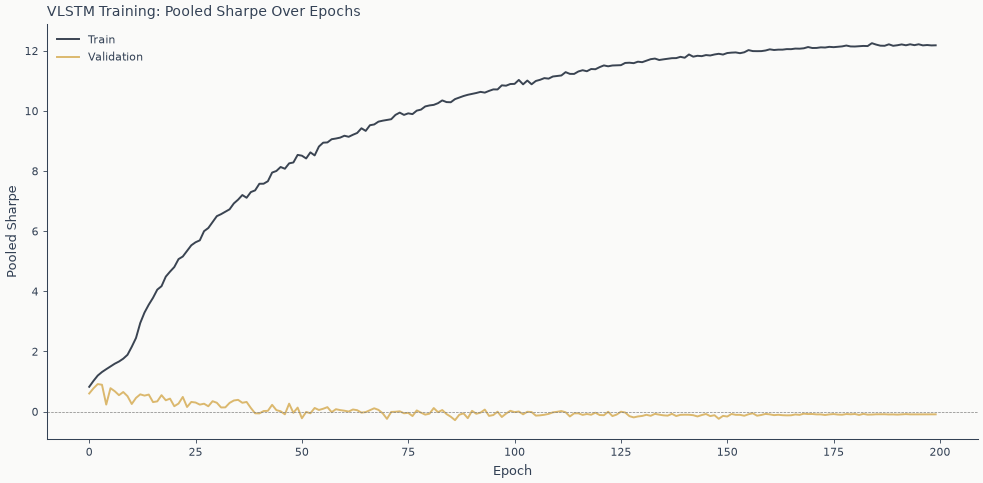

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
if train_sharpes and val_sharpes:
    ax.plot(train_sharpes, label="Train", alpha=0.8)
    ax.plot(val_sharpes, label="Validation", alpha=0.8)
    ax.legend()
else:
    ax.text(
        0.5,
        0.5,
        "Training history unavailable from cache",
        ha="center",
        va="center",
        transform=ax.transAxes,
    )
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Pooled Sharpe")
ax.set_title("VLSTM Training: Pooled Sharpe Over Epochs")
fig.tight_layout()
fig.show()

## 12. Out-of-Sample Evaluation

The comparison holds data and test window constant so any Sharpe difference reflects
the allocator, not the universe or the time slice.

In [26]:
model.load_state_dict(best_state)
model.eval()

VLSTM(
  (vsn): VariableSelectionNetwork(
    (feature_grns): ModuleList(
      (0-4): 5 x GatedResidualNetwork(
        (skip): Linear(in_features=1, out_features=32, bias=True)
        (dense1): Linear(in_features=1, out_features=32, bias=True)
        (dense2): Linear(in_features=32, out_features=32, bias=True)
        (gate): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
    )
    (selector): GatedResidualNetwork(
      (skip): Identity()
      (dense1): Linear(in_features=5, out_features=32, bias=True)
      (dense2): Linear(in_features=32, out_features=5, bias=True)
      (gate): Linear(in_features=5, out_features=10, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (norm): LayerNorm((5,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lstm): LSTM(32, 64, batch_first=True)
  (post_grn): GatedResidualNetwork(
    (skip): Identity()
   

In [27]:
@torch.no_grad()
def collect_test_arrays():
    sig_last, ret_last, vol_last = [], [], []
    for x_batch, r_batch, v_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        r_batch = r_batch.to(DEVICE)
        v_batch = v_batch.to(DEVICE)
        signal, _ = model(x_batch)
        sig_last.append(signal[:, -1, :].cpu().numpy())
        ret_last.append(r_batch[:, -1, :].cpu().numpy())
        vol_last.append(v_batch[:, -1, :].cpu().numpy())
    return (
        np.concatenate(sig_last, axis=0),
        np.concatenate(ret_last, axis=0),
        np.concatenate(vol_last, axis=0),
    )


test_signal, test_fwd, test_vol = collect_test_arrays()

Convert a learned scalar signal into volatility-targeted position weights (numpy mirror of `vol_scaled_positions`).

In [28]:
def positions_from_signal(signal: np.ndarray, vol_est: np.ndarray) -> np.ndarray:
    ann_vol = np.maximum(vol_est, 1e-4) * (252.0**0.5)
    n_assets = signal.shape[-1]
    return (VOL_TARGET_ANN / (ann_vol * n_assets)) * signal

Compute net-of-cost portfolio returns from a weight matrix and forward returns, charging `cost_bps` on turnover.

In [29]:
def strategy_returns(weights: np.ndarray, fwd: np.ndarray, cost_bps: float) -> np.ndarray:
    prev = np.vstack([np.zeros_like(weights[:1]), weights[:-1]])
    gross = (weights * fwd).sum(axis=1)
    turnover = np.abs(weights - prev).sum(axis=1)
    cost = turnover * (cost_bps / 10_000.0)
    return gross - cost

In [30]:
# VLSTM weights.
vlstm_weights = positions_from_signal(test_signal, test_vol)
vlstm_ret = strategy_returns(vlstm_weights, test_fwd, TURNOVER_COST_BPS)

# Equal-weight long-only benchmark (weights sum to 1).
eq_weights = np.ones_like(test_fwd) / N_ASSETS
eq_ret = strategy_returns(eq_weights, test_fwd, cost_bps=TURNOVER_COST_BPS)

# Inverse-volatility long-only benchmark.
inv_vol = 1.0 / np.maximum(test_vol, 1e-4)
iv_weights = inv_vol / inv_vol.sum(axis=1, keepdims=True)
iv_ret = strategy_returns(iv_weights, test_fwd, cost_bps=TURNOVER_COST_BPS)

### Performance Metrics

In [31]:
def metrics(returns: np.ndarray, name: str) -> dict:
    r = pd.Series(returns)
    mu = r.mean() * 252.0
    sigma = r.std() * (252.0**0.5)
    sharpe = mu / (sigma + 1e-8)
    cum = (1 + r).cumprod()
    dd = float((cum / cum.cummax() - 1).min())
    return {
        "Method": name,
        "Ann. Return": f"{mu:.1%}",
        "Ann. Vol": f"{sigma:.1%}",
        "Sharpe": f"{sharpe:+.2f}",
        "Max DD": f"{dd:.1%}",
    }


results = pd.DataFrame(
    [
        metrics(vlstm_ret, "VLSTM (long-short, vol-targeted)"),
        metrics(eq_ret, "Equal Weight"),
        metrics(iv_ret, "Inverse Volatility"),
    ]
)
print(results.to_string(index=False))
results

                          Method Ann. Return Ann. Vol Sharpe Max DD
VLSTM (long-short, vol-targeted)        4.9%     9.0%  +0.55 -17.6%
                    Equal Weight        7.9%    12.1%  +0.65 -18.4%
              Inverse Volatility        5.0%     8.2%  +0.60 -15.6%


,Method,Ann. Return,Ann. Vol,Sharpe,Max DD
0,"VLSTM (long-short, vol-targeted)",4.9%,9.0%,+0.55,-17.6%
1,Equal Weight,7.9%,12.1%,+0.65,-18.4%
2,Inverse Volatility,5.0%,8.2%,+0.60,-15.6%


In [32]:
def _sharpe(r):
    return float(pd.Series(r).mean() * 252.0 / (pd.Series(r).std() * (252.0**0.5) + 1e-8))


vlstm_sharpe = _sharpe(vlstm_ret)
ew_sharpe = _sharpe(eq_ret)
iv_sharpe = _sharpe(iv_ret)
_best_baseline = max(ew_sharpe, iv_sharpe)
_verdict = (
    "the zero-cost architectural edge does not survive this cost assumption"
    if vlstm_sharpe <= _best_baseline
    else "the architectural edge persists net of this cost assumption"
)
print(
    f"At {TURNOVER_COST_BPS:.0f} bps cost, VLSTM Sharpe {vlstm_sharpe:.2f} vs "
    f"EW {ew_sharpe:.2f} and IV {iv_sharpe:.2f}; {_verdict}."
)

At 5 bps cost, VLSTM Sharpe 0.55 vs EW 0.65 and IV 0.60; the zero-cost architectural edge does not survive this cost assumption.


### Equity Curves

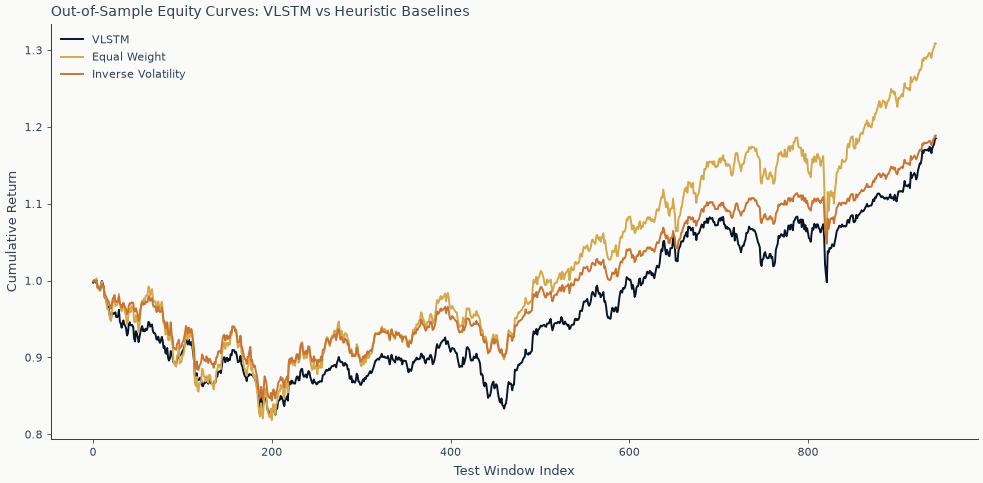

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
for arr, label in [
    (vlstm_ret, "VLSTM"),
    (eq_ret, "Equal Weight"),
    (iv_ret, "Inverse Volatility"),
]:
    ax.plot(np.cumprod(1 + arr), label=label)
ax.set_xlabel("Test Window Index")
ax.set_ylabel("Cumulative Return")
ax.set_title("Out-of-Sample Equity Curves: VLSTM vs Heuristic Baselines")
ax.legend()
fig.tight_layout()
fig.show()

**Trading implication**: If the VLSTM curve does not clear both heuristics net of the
in-loss cost deduction, the added complexity is not yet earning its keep on this
universe and cost regime.

## 13. Signal and Position Diagnostics

The scalar signal sits in $(-1, 1)$ and is converted into a signed position by the
volatility-targeting layer. A well-behaved learned allocator should produce (a) a
signal distribution that uses the full tanh range rather than collapsing to zero, and
(b) turnover that reflects genuine regime change rather than a high-frequency random
walk around neutral.

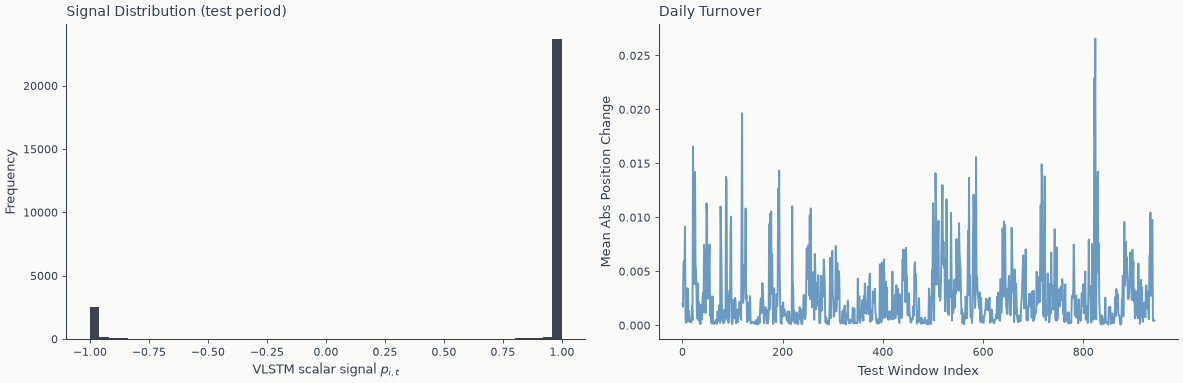

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_signal.reshape(-1), bins=50, alpha=0.8)
axes[0].set_xlabel("VLSTM scalar signal $p_{i,t}$")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Signal Distribution (test period)")

axes[1].plot(
    np.abs(np.diff(vlstm_weights, axis=0)).mean(axis=1),
    color="steelblue",
    alpha=0.8,
)
axes[1].set_xlabel("Test Window Index")
axes[1].set_ylabel("Mean Abs Position Change")
axes[1].set_title("Daily Turnover")

fig.tight_layout()
fig.show()

**Interpretation**: Signal concentration near zero indicates the vol-target is
dominating the actual exposure; a heavy-tailed signal distribution instead says the
network is expressing conviction and the final position is doing its job. Turnover
spikes that coincide with regime transitions are expected; persistent high turnover is
the implementation-cost risk flagged in the Saly-Kaufmann benchmark.

## 14. Variable Selection Weights

One reason to pay for VSN is interpretability. Averaging the selection weights over
the test period shows which inputs the model relies on.

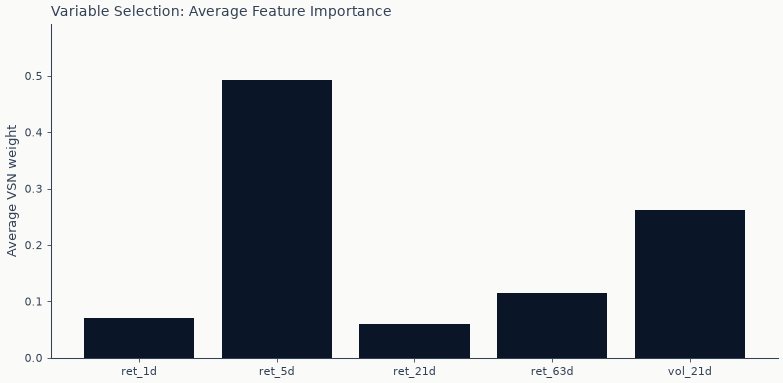

In [35]:
model.eval()
vsn_weights: list[np.ndarray] = []
with torch.no_grad():
    for x_batch, _, _ in test_loader:
        x_batch = x_batch.to(DEVICE)
        _, sel = model(x_batch)
        vsn_weights.append(sel[:, -1, :, :].cpu().numpy())
vsn_mean = np.concatenate(vsn_weights, axis=0).mean(axis=(0, 1))

feature_names = [f"ret_{h}d" for h in HORIZONS] + ["vol_21d"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(feature_names, vsn_mean)
ax.set_ylabel("Average VSN weight")
ax.set_title("Variable Selection: Average Feature Importance")
ax.set_ylim(0, max(vsn_mean.max() * 1.2, 1.0 / len(feature_names) * 2))
fig.tight_layout()
fig.show()

**Finding**: A concentrated VSN distribution says the model reduced the effective
feature set; a near-uniform distribution says selection added little over a plain
encoder, which is itself a useful diagnostic for whether the variable-selection
machinery is paying for itself on this universe.

## 15. Cost Sensitivity

The training loss already subtracts a 5 bps one-way turnover cost. This stress test
varies that assumption post-hoc on held-out weights to show how quickly the Sharpe of
each allocator erodes.

In [36]:
cost_grid = [0, 5, 10, 20, 50]
cost_rows = []
for cost_bps in cost_grid:
    row = {"One-way cost (bps)": cost_bps}
    for name, w, fwd in [
        ("VLSTM", vlstm_weights, test_fwd),
        ("Equal Weight", eq_weights, test_fwd),
        ("Inverse Vol", iv_weights, test_fwd),
    ]:
        r = strategy_returns(w, fwd, cost_bps=cost_bps)
        mu = r.mean() * 252.0
        sigma = r.std() * (252.0**0.5)
        row[name] = mu / (sigma + 1e-8)
    cost_rows.append(row)

cost_df = pd.DataFrame(cost_rows).set_index("One-way cost (bps)")
print(cost_df.round(2).to_string())
cost_df.round(2)

                    VLSTM  Equal Weight  Inverse Vol
One-way cost (bps)                                  
0                    0.66          0.65         0.62
5                    0.55          0.65         0.60
10                   0.44          0.65         0.59
20                   0.22          0.65         0.55
50                  -0.43          0.64         0.45


,VLSTM,Equal Weight,Inverse Vol
One-way cost (bps),,,
0,0.66,0.65,0.62
5,0.55,0.65,0.60
10,0.44,0.65,0.59
20,0.22,0.65,0.55
50,-0.43,0.64,0.45


**Trading implication**: The point at which the VLSTM Sharpe drops below a heuristic
alternative is the breakeven cost for the learned allocator on this universe. The
Saly-Kaufmann benchmark documents architecture rank changes as costs rise — the
ordering of xLSTM and VLSTM is not stable across the frictionless-to-realistic-cost
range — which is a reminder that architecture comparisons depend on the deployment
cost regime, not the zero-cost Sharpe alone. See Saly-Kaufmann et al. (2026) for
the figure-level details.

## 16. Key Takeaways

1. **Variable selection is the architectural innovation.** The VSN is a soft gate over
   TFT-style per-feature GRN embeddings; it lets the LSTM ingest a denoised
   representation rather than the raw feature stack.
2. **The portfolio layer matters as much as the encoder.** Scalar signal → vol-targeted
   long-short weights is the shared template that makes architecture comparisons in
   Saly-Kaufmann et al. (2026) fair; the same layer is what DeePM uses, with SoftMin
   added on top.
3. **Turnover cost is in the training loss, not added after the fact.** The model
   optimizes net-of-cost return at training time rather than receiving a post-hoc
   cost adjustment at evaluation. Whether the in-loss formulation strictly improves
   realized net Sharpe versus a post-hoc charge is not tested in this notebook.
4. **VLSTM is a bridge between the plain LSTM and DeePM.** Whatever Sharpe gap it
   leaves open against DeePM is the contribution of FiLM metadata conditioning, the
   macro graph prior, and the SoftMin objective — not of the encoder.

**Next**: `13_deepm_regime_robust` adds regime-aware structure on top of this base.

**Book**: §17.8 compares the simple LSTM, VLSTM, and DeePM under the same
end-to-end pipeline.